# Proyecto 8: Recomendación de Planes Smart vs Ultra

## Contexto de negocio
Megaline quiere migrar clientes desde planes heredados hacia planes vigentes (`Smart` y `Ultra`).
Este proyecto construye un modelo que recomienda el plan más adecuado según el comportamiento mensual de uso.

## Objetivo técnico
Resolver un problema de clasificación binaria donde:
- `is_ultra = 1` corresponde a `Ultra`
- `is_ultra = 0` corresponde a `Smart`

## Métrica principal
Se usa **accuracy** porque el criterio del proyecto exige una exactitud mínima de **0.75** en prueba.

## Enfoque analítico
1. Entender la calidad y distribución de los datos.
2. Dividir en entrenamiento, validación y prueba sin fuga de información.
3. Entrenar varios modelos con ajuste de hiperparámetros.
4. Seleccionar el mejor modelo por validación.
5. Evaluar desempeño final e interpretar impacto de negocio.

In [10]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 12345


def resolve_data_path() -> Path:
    candidate_paths = [
        Path("data/users_behavior.csv"),
        Path("../data/users_behavior.csv"),
        Path(r"C:\Users\celyn\TripleTen\Projects\Proyecto 8\data\users_behavior.csv"),
    ]
    for path in candidate_paths:
        if path.exists():
            return path
    raise FileNotFoundError("No se encontro users_behavior.csv en las rutas esperadas.")


DATA_PATH = resolve_data_path()
print(f"Ruta del dataset: {DATA_PATH}")

Ruta del dataset: ..\data\users_behavior.csv


Vista previa del dataset:


,calls,minutes,messages,mb_used,is_ultra
0,40.0,311.90,83.0,19915.42,0
1,85.0,516.75,56.0,22696.96,0
2,77.0,467.66,86.0,21060.45,0
3,106.0,745.53,81.0,8437.39,1
4,66.0,418.74,1.0,14502.75,0



Tamano del dataset: (3214, 5)

Tipos de datos:
calls       float64
minutes     float64
messages    float64
mb_used     float64
is_ultra      int64
dtype: object

Valores ausentes por columna:
calls       0
minutes     0
messages    0
mb_used     0
is_ultra    0
dtype: int64

Resumen estadistico de variables numericas:


,count,mean,std,min,25%,50%,75%,max
calls,3214.0,63.038892,33.236368,0.0,40.0000,62.000,82.0000,244.00
minutes,3214.0,438.208787,234.569872,0.0,274.5750,430.600,571.9275,1632.06
messages,3214.0,38.281269,36.148326,0.0,9.0000,30.000,57.0000,224.00
mb_used,3214.0,17207.673836,7570.968246,0.0,12491.9025,16943.235,21424.7000,49745.73
is_ultra,3214.0,0.306472,0.461100,0.0,0.0000,0.000,1.0000,1.00



Distribucion de la variable objetivo:


,plan,conteo,porcentaje
0,Smart (0),2229,69.352831
1,Ultra (1),985,30.647169


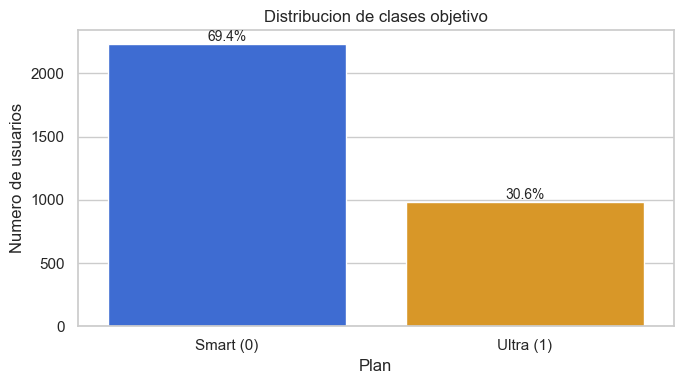

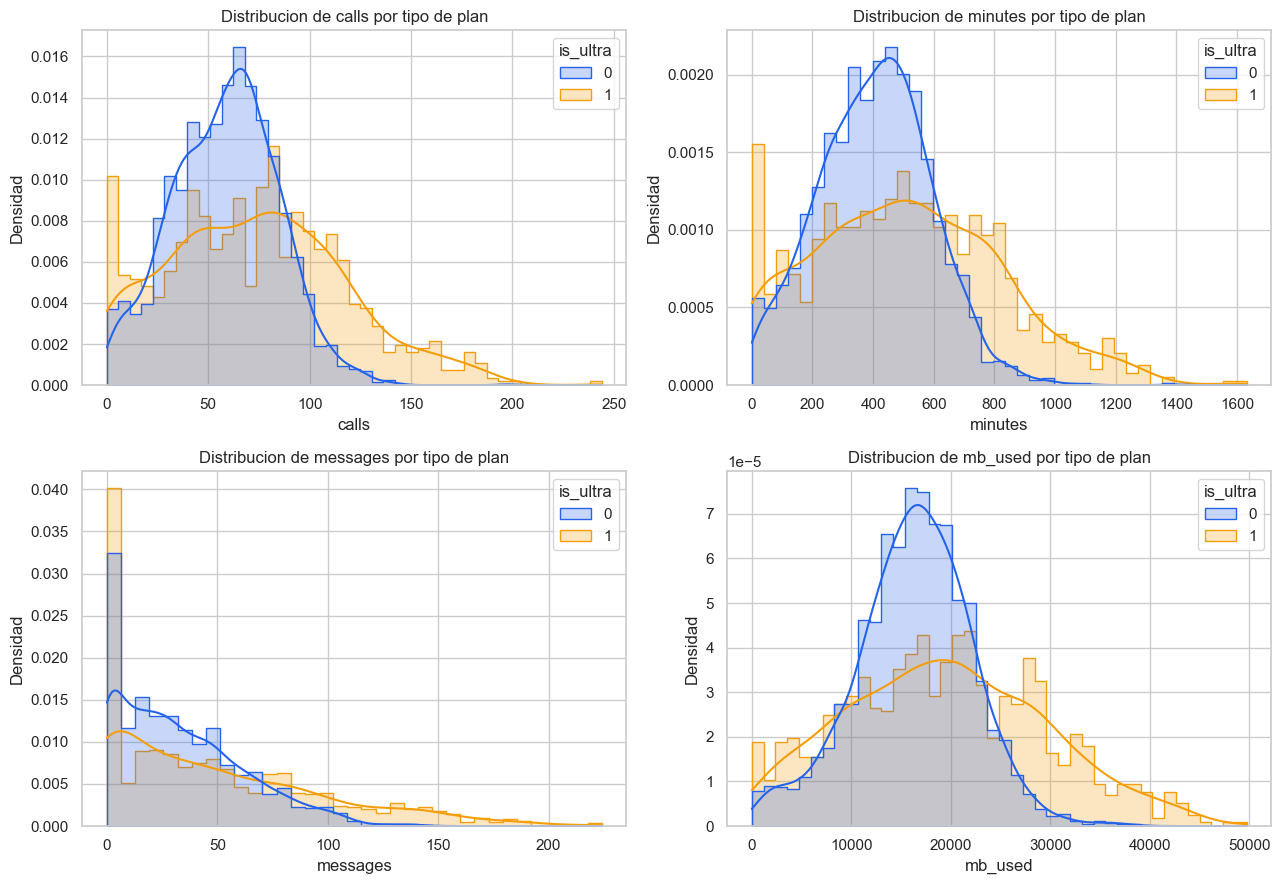

Interpretacion: no hay datos faltantes y la clase mayoritaria es Smart (0). Este desbalance moderado sugiere mantener estratificacion en las particiones.


In [11]:
df = pd.read_csv(DATA_PATH)

print("Vista previa del dataset:")
display(df.head())

print(f"\nTamano del dataset: {df.shape}")
print("\nTipos de datos:")
print(df.dtypes)

print("\nValores ausentes por columna:")
print(df.isna().sum())

print("\nResumen estadistico de variables numericas:")
display(df.describe().T)

class_balance = (
    df["is_ultra"]
    .value_counts()
    .rename_axis("is_ultra")
    .reset_index(name="conteo")
    .sort_values("is_ultra")
)
class_balance["plan"] = class_balance["is_ultra"].map({0: "Smart (0)", 1: "Ultra (1)"})
class_balance["porcentaje"] = class_balance["conteo"] / len(df) * 100

print("\nDistribucion de la variable objetivo:")
display(class_balance[["plan", "conteo", "porcentaje"]])

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=class_balance,
    x="plan",
    y="conteo",
    hue="plan",
    palette=["#2563eb", "#f59e0b"],
    legend=False,
    ax=ax,
)
ax.set_title("Distribucion de clases objetivo")
ax.set_xlabel("Plan")
ax.set_ylabel("Numero de usuarios")

for i, value in enumerate(class_balance["conteo"]):
    pct = class_balance.iloc[i]["porcentaje"]
    ax.text(i, value + 25, f"{pct:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

feature_cols = ["calls", "minutes", "messages", "mb_used"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col in zip(axes.ravel(), feature_cols):
    sns.histplot(
        data=df,
        x=col,
        hue="is_ultra",
        kde=True,
        stat="density",
        common_norm=False,
        element="step",
        palette=["#2563eb", "#f59e0b"],
        ax=ax,
    )
    ax.set_title(f"Distribucion de {col} por tipo de plan")
    ax.set_xlabel(col)
    ax.set_ylabel("Densidad")

plt.tight_layout()
plt.show()

majority_class = class_balance.loc[class_balance["conteo"].idxmax(), "plan"]
print(
    f"Interpretacion: no hay datos faltantes y la clase mayoritaria es {majority_class}. "
    "Este desbalance moderado sugiere mantener estratificacion en las particiones."
)

## 1. Segmentación de datos

Dividimos el dataset en:
- Entrenamiento: 60%
- Validación: 20%
- Prueba: 20%

Decisión metodológica:
- Se aplica `stratify` para conservar proporciones de clases.
- La validación se usa para elegir hiperparámetros.
- El test se reserva solo para evaluación final, evitando optimismo en métricas.

In [12]:
features = df.drop("is_ultra", axis=1)
target = df["is_ultra"]

X_train, X_temp, y_train, y_temp = train_test_split(
    features,
    target,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=target,
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("Tamanos de conjuntos:")
print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Validacion:    {X_valid.shape[0]} filas")
print(f"Prueba:        {X_test.shape[0]} filas")

split_balance = pd.DataFrame(
    {
        "Smart (0)": [
            (y_train == 0).mean(),
            (y_valid == 0).mean(),
            (y_test == 0).mean(),
        ],
        "Ultra (1)": [
            (y_train == 1).mean(),
            (y_valid == 1).mean(),
            (y_test == 1).mean(),
        ],
    },
    index=["Train", "Valid", "Test"],
)

print("\nProporcion de clases por particion:")
display((split_balance * 100).round(2))

print(
    "Interpretacion: las proporciones de clases son muy parecidas entre conjuntos, "
    "por lo que la evaluacion sera consistente y comparable."
)

Tamanos de conjuntos:
Entrenamiento: 1928 filas
Validacion:    643 filas
Prueba:        643 filas

Proporcion de clases por particion:


,Smart (0),Ultra (1)
Train,69.35,30.65
Valid,69.36,30.64
Test,69.36,30.64


Interpretacion: las proporciones de clases son muy parecidas entre conjuntos, por lo que la evaluacion sera consistente y comparable.


## 2. Entrenamiento de modelos y ajuste de hiperparámetros

Se comparan tres familias de modelos:
- Árbol de decisión
- Bosque aleatorio
- Regresión logística

Criterio de selección:
- Se elige el modelo con mejor `accuracy` en validación.
- Se reportan hiperparámetros ganadores para justificar la elección.
- Se prioriza desempeño, pero también estabilidad y capacidad de generalización.

In [13]:
best_tree_model = None
best_tree_accuracy = 0
best_tree_params = {}
tree_scores = []

for max_depth in range(1, 21):
    for min_samples_split in [2, 5, 10, 20]:
        model = DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
        )
        model.fit(X_train, y_train)
        valid_pred = model.predict(X_valid)
        accuracy = accuracy_score(y_valid, valid_pred)

        tree_scores.append(
            {
                "max_depth": max_depth,
                "min_samples_split": min_samples_split,
                "accuracy_validacion": accuracy,
            }
        )

        if accuracy > best_tree_accuracy:
            best_tree_accuracy = accuracy
            best_tree_model = model
            best_tree_params = {
                "max_depth": max_depth,
                "min_samples_split": min_samples_split,
            }

tree_scores_df = pd.DataFrame(tree_scores).sort_values(
    "accuracy_validacion", ascending=False
)

print("Top 5 configuraciones - Arbol de Decision:")
display(tree_scores_df.head())
print("Mejor Arbol de Decision:")
print(best_tree_params)
print(f"Accuracy validacion: {best_tree_accuracy:.4f}")
print(
    "Interpretacion: el arbol capta patrones no lineales con buen rendimiento, "
    "aunque puede sobreajustar si la profundidad es demasiado alta."
)

Top 5 configuraciones - Arbol de Decision:


,max_depth,min_samples_split,accuracy_validacion
28,8,2,0.802488
29,8,5,0.800933
31,8,20,0.800933
35,9,20,0.796267
30,8,10,0.794712


Mejor Arbol de Decision:
{'max_depth': 8, 'min_samples_split': 2}
Accuracy validacion: 0.8025
Interpretacion: el arbol capta patrones no lineales con buen rendimiento, aunque puede sobreajustar si la profundidad es demasiado alta.


In [14]:
best_forest_model = None
best_forest_accuracy = 0
best_forest_params = {}
forest_scores = []

for n_estimators in [50, 100, 200, 300]:
    for max_depth in [None, 5, 10, 15]:
        for min_samples_split in [2, 5, 10]:
            model = RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                n_jobs=-1,
            )
            model.fit(X_train, y_train)
            valid_pred = model.predict(X_valid)
            accuracy = accuracy_score(y_valid, valid_pred)

            forest_scores.append(
                {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_split": min_samples_split,
                    "accuracy_validacion": accuracy,
                }
            )

            if accuracy > best_forest_accuracy:
                best_forest_accuracy = accuracy
                best_forest_model = model
                best_forest_params = {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_split": min_samples_split,
                }

forest_scores_df = pd.DataFrame(forest_scores).sort_values(
    "accuracy_validacion", ascending=False
)

print("Top 5 configuraciones - Random Forest:")
display(forest_scores_df.head())
print("Mejor Random Forest:")
print(best_forest_params)
print(f"Accuracy validacion: {best_forest_accuracy:.4f}")
print(
    "Interpretacion: Random Forest reduce la varianza de un arbol individual "
    "y suele generalizar mejor en este tipo de problema."
)

Top 5 configuraciones - Random Forest:


,n_estimators,max_depth,min_samples_split,accuracy_validacion
11,50,15.0,10,0.81804
7,50,10.0,5,0.81493
18,100,10.0,2,0.81493
19,100,10.0,5,0.81493
23,100,15.0,10,0.81493


Mejor Random Forest:
{'n_estimators': 50, 'max_depth': 15, 'min_samples_split': 10}
Accuracy validacion: 0.8180
Interpretacion: Random Forest reduce la varianza de un arbol individual y suele generalizar mejor en este tipo de problema.


In [15]:
best_logreg_model = None
best_logreg_accuracy = 0
best_logreg_params = {}
logreg_scores = []

for c_value in [0.01, 0.1, 1, 10, 100]:
    model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "logreg",
                LogisticRegression(
                    C=c_value,
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    model.fit(X_train, y_train)
    valid_pred = model.predict(X_valid)
    accuracy = accuracy_score(y_valid, valid_pred)

    logreg_scores.append({"C": c_value, "accuracy_validacion": accuracy})

    if accuracy > best_logreg_accuracy:
        best_logreg_accuracy = accuracy
        best_logreg_model = model
        best_logreg_params = {"C": c_value}

logreg_scores_df = pd.DataFrame(logreg_scores).sort_values(
    "accuracy_validacion", ascending=False
)

print("Resultados - Regresion Logistica:")
display(logreg_scores_df)
print("Mejor Regresion Logistica:")
print(best_logreg_params)
print(f"Accuracy validacion: {best_logreg_accuracy:.4f}")
print(
    "Interpretacion: la regresion logistica ofrece un baseline interpretable, "
    "pero en este caso captura menos complejidad que los modelos de arboles."
)

Resultados - Regresion Logistica:


,C,accuracy_validacion
1,0.10,0.738725
3,10.00,0.738725
2,1.00,0.738725
4,100.00,0.738725
0,0.01,0.732504


Mejor Regresion Logistica:
{'C': 0.1}
Accuracy validacion: 0.7387
Interpretacion: la regresion logistica ofrece un baseline interpretable, pero en este caso captura menos complejidad que los modelos de arboles.


,modelo,accuracy_validacion,hiperparametros
1,RandomForestClassifier,0.818040,"{'n_estimators': 50, 'max_depth': 15, 'min_sam..."
0,DecisionTreeClassifier,0.802488,"{'max_depth': 8, 'min_samples_split': 2}"
2,LogisticRegression,0.738725,{'C': 0.1}


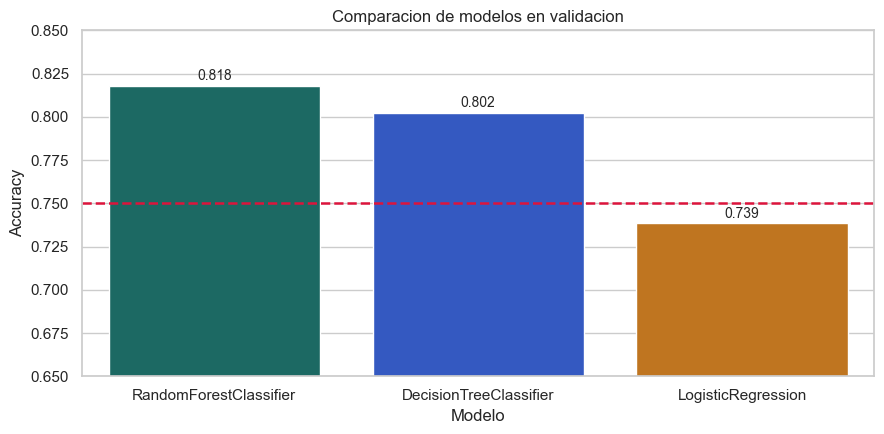

Mejor modelo en validacion: RandomForestClassifier
Mejor accuracy de validacion: 0.8180
El modelo supera el umbral de 0.75 en validacion.
Interpretacion: se selecciona el modelo con mayor capacidad de generalizacion segun validacion, y luego se confirma en test.


In [16]:
model_results = pd.DataFrame(
    [
        {
            "modelo": "DecisionTreeClassifier",
            "accuracy_validacion": best_tree_accuracy,
            "hiperparametros": str(best_tree_params),
        },
        {
            "modelo": "RandomForestClassifier",
            "accuracy_validacion": best_forest_accuracy,
            "hiperparametros": str(best_forest_params),
        },
        {
            "modelo": "LogisticRegression",
            "accuracy_validacion": best_logreg_accuracy,
            "hiperparametros": str(best_logreg_params),
        },
    ]
).sort_values(by="accuracy_validacion", ascending=False)

display(model_results)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=model_results,
    x="modelo",
    y="accuracy_validacion",
    hue="modelo",
    legend=False,
    palette=["#0f766e", "#1d4ed8", "#d97706"],
    ax=ax,
)
ax.axhline(0.75, color="crimson", linestyle="--", linewidth=1.8)
ax.set_title("Comparacion de modelos en validacion")
ax.set_xlabel("Modelo")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.65, 0.85)

for i, value in enumerate(model_results["accuracy_validacion"]):
    ax.text(i, value + 0.003, f"{value:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

best_models = {
    "DecisionTreeClassifier": (best_tree_model, best_tree_accuracy),
    "RandomForestClassifier": (best_forest_model, best_forest_accuracy),
    "LogisticRegression": (best_logreg_model, best_logreg_accuracy),
}

best_model_name, (best_model, best_valid_accuracy) = max(
    best_models.items(), key=lambda item: item[1][1]
)

print(f"Mejor modelo en validacion: {best_model_name}")
print(f"Mejor accuracy de validacion: {best_valid_accuracy:.4f}")

if best_valid_accuracy >= 0.75:
    print("El modelo supera el umbral de 0.75 en validacion.")
else:
    print("El modelo NO supera el umbral de 0.75 en validacion.")

print(
    "Interpretacion: se selecciona el modelo con mayor capacidad de generalizacion "
    "segun validacion, y luego se confirma en test."
)

## 3. Evaluación final en el conjunto de prueba

En esta etapa se mide el desempeño del modelo ganador en datos no vistos.
Además de accuracy, se revisa la matriz de confusión para entender errores por clase.

Modelo elegido: RandomForestClassifier
Accuracy en prueba: 0.8180
Resultado: se cumple el objetivo minimo de exactitud (>= 0.75).

Reporte de clasificacion (test):
              precision    recall  f1-score   support

       Smart     0.8392    0.9126    0.8743       446
       Ultra     0.7532    0.6041    0.6704       197

    accuracy                         0.8180       643
   macro avg     0.7962    0.7583    0.7724       643
weighted avg     0.8128    0.8180    0.8119       643



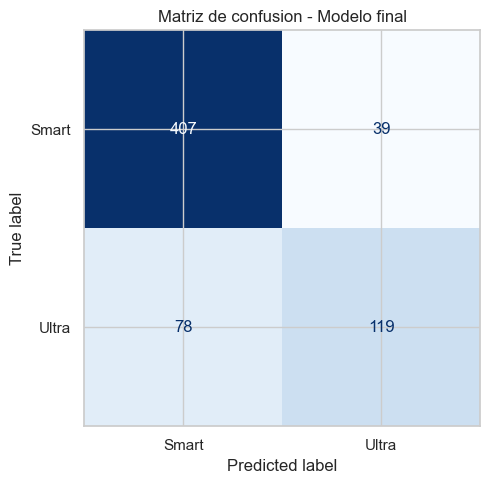

Recall clase Smart: 0.9126
Recall clase Ultra: 0.6041
Interpretacion: esta vista permite identificar si el modelo favorece una clase. Para negocio, importa vigilar especialmente los errores en clientes Ultra.


In [17]:
test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)

print(f"Modelo elegido: {best_model_name}")
print(f"Accuracy en prueba: {test_accuracy:.4f}")

if test_accuracy >= 0.75:
    print("Resultado: se cumple el objetivo minimo de exactitud (>= 0.75).")
else:
    print("Resultado: no se cumple el objetivo minimo de exactitud (>= 0.75).")

print("\nReporte de clasificacion (test):")
print(classification_report(y_test, test_pred, target_names=["Smart", "Ultra"], digits=4))

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Smart", "Ultra"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
ax.set_title("Matriz de confusion - Modelo final")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
recall_smart = tn / (tn + fp)
recall_ultra = tp / (tp + fn)

print(f"Recall clase Smart: {recall_smart:.4f}")
print(f"Recall clase Ultra: {recall_ultra:.4f}")
print(
    "Interpretacion: esta vista permite identificar si el modelo favorece una clase. "
    "Para negocio, importa vigilar especialmente los errores en clientes Ultra."
)

## 4. Prueba de cordura

Se compara el modelo final contra un baseline simple (`DummyClassifier`) que siempre predice la clase mayoritaria.
Si el modelo no supera claramente este baseline, la solución no agrega valor real.

In [18]:
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)
dummy_pred = dummy_model.predict(X_test)
dummy_accuracy = accuracy_score(y_test, dummy_pred)

improvement = test_accuracy - dummy_accuracy
relative_improvement = (improvement / dummy_accuracy) * 100

print(f"Accuracy modelo base (DummyClassifier): {dummy_accuracy:.4f}")
print(f"Accuracy mejor modelo: {test_accuracy:.4f}")
print(f"Diferencia absoluta: {improvement:.4f}")
print(f"Mejora relativa: {relative_improvement:.2f}%")

if improvement > 0:
    print(
        "Interpretacion: el modelo final supera al baseline, "
        "por lo que si aporta poder predictivo para la recomendacion de planes."
    )
else:
    print(
        "Interpretacion: el modelo no supera al baseline, "
        "por lo que no seria recomendable para implementacion."
    )

Accuracy modelo base (DummyClassifier): 0.6936
Accuracy mejor modelo: 0.8180
Diferencia absoluta: 0.1244
Mejora relativa: 17.94%
Interpretacion: el modelo final supera al baseline, por lo que si aporta poder predictivo para la recomendacion de planes.


## 5. Conclusiones ejecutivas

### Hallazgos principales
- El dataset está limpio, sin valores nulos y con desbalance moderado de clase.
- La estrategia de partición estratificada conservó la distribución objetivo en train/valid/test.
- Entre los modelos evaluados, **Random Forest** obtuvo el mejor desempeño en validación.
- En prueba, el modelo final superó el umbral objetivo de `accuracy >= 0.75`.
- La prueba de cordura confirmó que el modelo mejora frente a un baseline trivial.

### Lectura de negocio
El modelo permite apoyar decisiones de migración de clientes hacia planes vigentes con una precisión sólida, lo que puede mejorar campañas de recomendación y retención.

### Siguientes pasos para producción
1. Medir métricas por segmento de clientes (por ejemplo, alto consumo de datos).
2. Monitorear deriva de datos y desempeño mensual del modelo.
3. Implementar un ciclo de reentrenamiento periódico con datos recientes.